###SETUP
Connect to drive and install captum, which is not usually available for a regular Colab session and needs to be manually installed.

Then, import the whitebox package from the Git repository.

Please do note that the paths are based on my directory organization at the time of writing this, and that if you are not working in Colab because you somehow have storage for the entire dataset on your PC, you should skip the first cell.

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

!pip install captum #usually this is not available by default

In [15]:
import sys
sys.path.append("/content/drive/MyDrive/Semester_7/BDD/whitebox_clean/") # change the paths

from whitebox import (
    load_rescnn,
    load_breakhis_sample,
    generate_gradcam,
    show_gradcam_on_image,
    run_occlusion_head1,
    show_occlusion_on_image,
    saliency_pearson,
    saliency_difference,
)



In [16]:
weights_path = "/content/drive/MyDrive/Semester_7/BDD/ResCNN_best.pth" # change the paths

model = load_rescnn(weights_path, device ="cpu") # load the stored model

### Example Run

You just pick an index to analyze and hit play to generate the visuals.

Runs Grad-Cam, Occlusion, Difference (Occ-GC), and Pearson value.

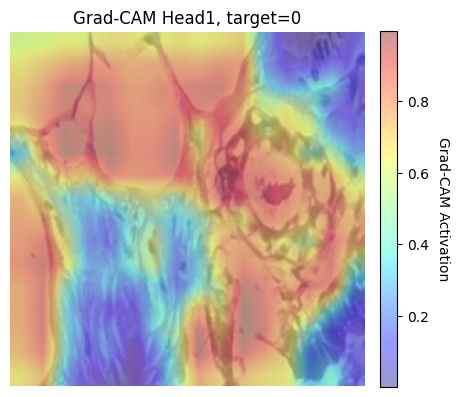

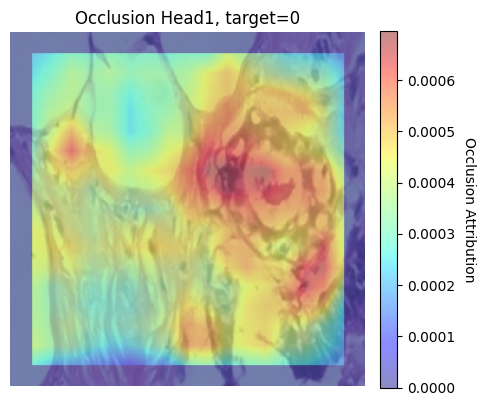

Grad-CAM target class: 0
Occlusion target class: 0
P(target): 0.9984
Pearson r: 0.3788


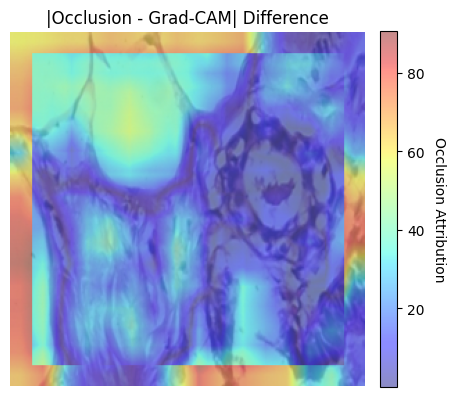

In [5]:
METADATA_CSV = "/content/drive/MyDrive/Semester_7/BDD/data/BreaKHis_v1/BreaKHis_v1/histology_slides/breast/BreaKHis_metadata.csv" #change the paths

# See documentation comments for each function's options and...function

sample_index = 1 # choose an example by index

sample = load_breakhis_sample(METADATA_CSV, sample_index)
img_tensor = sample["image_tensor"]
magn_token = sample["magn_token"]

# Run the Grad-Cam.  This is on the order of seconds.
cam, gradcam_target = generate_gradcam(model, img_tensor, magn_token, target_head="head1")
show_gradcam_on_image(img_tensor, cam, title=f"Grad-CAM Head1, target={gradcam_target}")

# Run the Occlusion.  Depending on the parameters you choose, this usually takes ~5 minutes to run
occ = run_occlusion_head1(model, img_tensor, magn_token, window_hw=32, stride_hw=14, baseline_mode="zero")
show_occlusion_on_image(img_tensor, occ["heat"], title=f"Occlusion Head1, target={occ['target_class']}")

print(f"Grad-CAM target class: {gradcam_target}")
print(f"Occlusion target class: {occ['target_class']}")
print(f"P(target): {occ['p_target']:.4f}")
print(f"Pearson r: {saliency_pearson(cam, occ['heat']):.4f}")

diff = saliency_difference(cam, occ["heat"])
show_occlusion_on_image(img_tensor, diff, title="|Occlusion - Grad-CAM| Difference")